# Aurora Siger - Fase 3
## A Aurora Estabelece os Primeiros Sistemas da Colonia

Notebook executavel do sistema inteligente de operacao continua da colonia Aurora Siger em Marte.

O sistema integra cinco eixos:

1. **Estruturas de dados** - listas, dicionarios (chave-valor), hierarquias e **arrays NumPy**.
2. **Logica de decisao** - condicoes simples e combinadas com `if/elif/else`.
3. **Modelagem matematica** - funcoes vetorizadas com NumPy para geracao solar, eolica e consumo.
4. **Previsao** - regressao linear simples via minimos quadrados vetorizados.
5. **Eficiencia energetica** - comparacao geracao x consumo e recomendacoes.

> **NumPy em destaque**: dados numericos sao organizados como `ndarray` (arrays 1D e 2D) e as operacoes matematicas usam vetorizacao e broadcasting para evitar loops e ganhar performance.

## 1. Importacao das bibliotecas

Apenas bibliotecas basicas, conforme orientacao da atividade (foco em logica e organizacao, sem dependencias avancadas como `scikit-learn`).

- **NumPy**: arrays n-dimensionais e operacoes vetorizadas.
- **pandas**: tabelas para exibir resultados.
- **matplotlib**: graficos.

In [1]:
import importlib
import subprocess
import sys

pacotes = ["matplotlib", "numpy", "pandas"]
for pacote in pacotes:
    try:
        importlib.import_module(pacote)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pacote])

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8")

## 2. Estruturacao dos dados da colonia

Os dados sao organizados em tres niveis complementares:

- **Hierarquia** dos subsistemas (energetico -> solar / eolico, ambiental, operacional).
- **Dicionario (chave-valor)** com a leitura atual de cada sensor.
- **Listas (series historicas)** com as ultimas leituras, usadas para analise e previsao.

In [2]:
colonia = {
    "energetico": {
        "solar": {"geracao_kw": 32.0, "status": "ok"},
        "eolico": {"geracao_kw": 18.0, "status": "ok"},
        "reserva_bateria_pct": 64.0,
    },
    "ambiental": {
        "temperatura_interna_c": 21.5,
        "temperatura_externa_c": -58.0,
        "velocidade_vento_ms": 9.2,
    },
    "operacional": {
        "consumo_kw": 45.0,
        "modulos": {
            "suporte_vida": {"essencial": True, "consumo_kw": 18.0, "ligado": True},
            "habitacao": {"essencial": True, "consumo_kw": 9.0, "ligado": True},
            "laboratorio": {"essencial": False, "consumo_kw": 7.0, "ligado": True},
            "estufa": {"essencial": False, "consumo_kw": 6.0, "ligado": True},
            "comunicacao": {"essencial": True, "consumo_kw": 5.0, "ligado": True},
        },
    },
}

historico = {
    "hora":              np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]),
    "vento_ms":          np.array([4.0, 5.0, 5.5, 6.0, 6.5, 7.0, 8.0, 8.5, 9.0, 9.2, 9.8, 10.0]),
    "energia_eolica_kw": np.array([8, 10, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22], dtype=float),
    "geracao_solar_kw":  np.array([0, 0, 5, 14, 22, 28, 32, 33, 31, 25, 17, 8], dtype=float),
    "consumo_kw":        np.array([38, 38, 40, 42, 45, 48, 50, 52, 50, 47, 45, 43], dtype=float),
}

print("Cada serie e um array 1D do NumPy:")
print(f"  shape do vetor vento     : {historico['vento_ms'].shape}")
print(f"  dtype do vetor vento     : {historico['vento_ms'].dtype}")
print(f"  vento medio (np.mean)    : {historico['vento_ms'].mean():.2f} m/s")
print(f"  consumo maximo (np.max)  : {historico['consumo_kw'].max():.1f} kW")

df_historico = pd.DataFrame(historico)
df_historico

Cada serie e um array 1D do NumPy:
  shape do vetor vento     : (12,)
  dtype do vetor vento     : float64
  vento medio (np.mean)    : 7.38 m/s
  consumo maximo (np.max)  : 52.0 kW


,hora,vento_ms,energia_eolica_kw,geracao_solar_kw,consumo_kw
0,0,4.0,8.0,0.0,38.0
1,1,5.0,10.0,0.0,38.0
2,2,5.5,12.0,5.0,40.0
3,3,6.0,13.0,14.0,42.0
4,4,6.5,14.0,22.0,45.0
5,5,7.0,15.0,28.0,48.0
6,6,8.0,17.0,32.0,50.0
7,7,8.5,18.0,33.0,52.0
8,8,9.0,19.0,31.0,50.0
9,9,9.2,20.0,25.0,47.0


In [3]:
def listar_subsistemas(estrutura, nivel=0):
    """Percorre a hierarquia da colonia mostrando os subsistemas e seus dados."""
    for chave, valor in estrutura.items():
        prefixo = "  " * nivel + "- "
        if isinstance(valor, dict):
            print(f"{prefixo}{chave}")
            listar_subsistemas(valor, nivel + 1)
        else:
            print(f"{prefixo}{chave}: {valor}")

listar_subsistemas(colonia)

- energetico
  - solar
    - geracao_kw: 32.0
    - status: ok
  - eolico
    - geracao_kw: 18.0
    - status: ok
  - reserva_bateria_pct: 64.0
- ambiental
  - temperatura_interna_c: 21.5
  - temperatura_externa_c: -58.0
  - velocidade_vento_ms: 9.2
- operacional
  - consumo_kw: 45.0
  - modulos
    - suporte_vida
      - essencial: True
      - consumo_kw: 18.0
      - ligado: True
    - habitacao
      - essencial: True
      - consumo_kw: 9.0
      - ligado: True
    - laboratorio
      - essencial: False
      - consumo_kw: 7.0
      - ligado: True
    - estufa
      - essencial: False
      - consumo_kw: 6.0
      - ligado: True
    - comunicacao
      - essencial: True
      - consumo_kw: 5.0
      - ligado: True


In [4]:
geracao_total_atual = (
    colonia["energetico"]["solar"]["geracao_kw"]
    + colonia["energetico"]["eolico"]["geracao_kw"]
)
consumo_total_atual = colonia["operacional"]["consumo_kw"]
reserva_atual = colonia["energetico"]["reserva_bateria_pct"]

print(f"Geracao total atual: {geracao_total_atual:.1f} kW")
print(f"Consumo total atual: {consumo_total_atual:.1f} kW")
print(f"Reserva de bateria : {reserva_atual:.1f} %")

Geracao total atual: 50.0 kW
Consumo total atual: 45.0 kW
Reserva de bateria : 64.0 %


## 3. Logica de decisao do sistema

As regras combinam condicoes simples sobre energia, consumo e previsao para gerar uma acao clara.

Exemplo do enunciado: `entrada -> energia = 40, consumo = 70` resulta em `saida -> "ALERTA: reduzir consumo"`.

In [5]:
def avaliar_energia(geracao, consumo, reserva):
    """Regra simples baseada apenas na relacao geracao/consumo e reserva."""
    if consumo > geracao and reserva < 30:
        return "ALERTA: consumo maior que geracao e reserva baixa"
    if consumo > geracao:
        return "ATENCAO: consumo acima da geracao, usando reserva"
    if geracao > consumo * 1.3:
        return "SUGESTAO: armazenar energia excedente"
    return "OK: operacao equilibrada"


def decidir_modo_operacao(geracao, consumo, reserva, previsao_geracao):
    """Combina varias condicoes para escolher o modo de operacao da colonia."""
    saldo = geracao - consumo
    previsao_saldo = previsao_geracao - consumo

    if reserva < 20 and saldo < 0 and previsao_saldo < 0:
        return "MODO CRITICO"
    if reserva < 50 and saldo < 0:
        return "MODO ECONOMIA"
    if saldo > 0 and reserva > 80:
        return "MODO EXCEDENTE"
    return "MODO NORMAL"


def priorizar_modulos(modulos, modo):
    """Em modos restritivos, desliga modulos nao essenciais para manter suporte a vida."""
    resultado = {}
    for nome, dados in modulos.items():
        novo = dados.copy()
        if modo == "MODO CRITICO" and not dados["essencial"]:
            novo["ligado"] = False
        elif modo == "MODO ECONOMIA" and not dados["essencial"] and dados["consumo_kw"] > 5:
            novo["ligado"] = False
        else:
            novo["ligado"] = True
        resultado[nome] = novo
    return resultado

In [6]:
exemplos = [
    {"geracao": 40, "consumo": 70, "reserva": 25},
    {"geracao": 80, "consumo": 30, "reserva": 90},
    {"geracao": 50, "consumo": 55, "reserva": 60},
    {"geracao": 60, "consumo": 50, "reserva": 70},
]

for caso in exemplos:
    acao = avaliar_energia(caso["geracao"], caso["consumo"], caso["reserva"])
    print(
        f"Entrada: geracao={caso['geracao']} kW, consumo={caso['consumo']} kW, reserva={caso['reserva']}%"
    )
    print(f"Saida  : {acao}\n")

Entrada: geracao=40 kW, consumo=70 kW, reserva=25%
Saida  : ALERTA: consumo maior que geracao e reserva baixa

Entrada: geracao=80 kW, consumo=30 kW, reserva=90%
Saida  : SUGESTAO: armazenar energia excedente

Entrada: geracao=50 kW, consumo=55 kW, reserva=60%
Saida  : ATENCAO: consumo acima da geracao, usando reserva

Entrada: geracao=60 kW, consumo=50 kW, reserva=70%
Saida  : OK: operacao equilibrada



## 4. Modelagem matematica da geracao e do consumo

Sao usados modelos matematicos simples para representar fenomenos da colonia:

- **Geracao solar** em funcao do horario: aproximacao senoidal entre o nascer e o por do sol.
- **Geracao eolica** em funcao da velocidade do vento: relacao linear (potencia disponivel cresce com o vento).
- **Consumo** ao longo do dia: comportamento aproximadamente parabolico (pico no meio do dia).

Operacoes vetorizadas (sem loops):
  horas.shape   = (24,)
  solar.shape   = (24,)  (mesma forma -> broadcasting OK)
  consumo medio = 46.2 kW
  pico solar    = 33.0 kW as 6.0 h


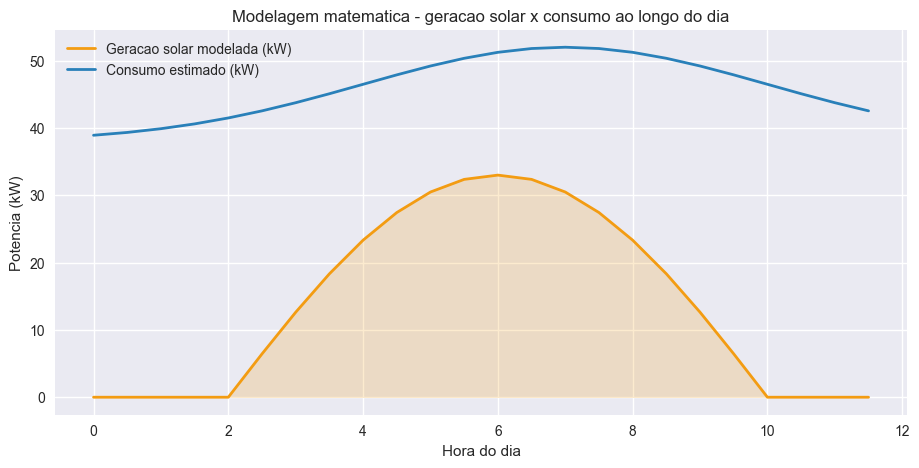

In [7]:
def geracao_solar(hora, pico=33, nascer=2, por=10):
    """Curva senoidal vetorizada entre nascer e por do sol.

    Aceita tanto escalares quanto arrays NumPy (broadcasting).
    """
    hora = np.asarray(hora, dtype=float)
    fracao = (hora - nascer) / (por - nascer)
    ativo = (hora > nascer) & (hora < por)
    return np.where(ativo, pico * np.sin(np.pi * fracao), 0.0)


def geracao_eolica(vento_ms, coef_a=2.0, coef_b=0.0):
    """Relacao linear vetorizada entre vento e energia eolica."""
    vento_ms = np.asarray(vento_ms, dtype=float)
    return np.maximum(0.0, coef_a * vento_ms + coef_b)


def consumo_estimado(hora, base=38.0, amplitude=14.0, pico_hora=7.0, sigma2=18.0):
    """Modelo gaussiano vetorizado do consumo ao longo do dia."""
    hora = np.asarray(hora, dtype=float)
    return base + amplitude * np.exp(-((hora - pico_hora) ** 2) / sigma2)


horas = np.arange(0, 12, 0.5)
solar = geracao_solar(horas)
consumo = consumo_estimado(horas)

print("Operacoes vetorizadas (sem loops):")
print(f"  horas.shape   = {horas.shape}")
print(f"  solar.shape   = {solar.shape}  (mesma forma -> broadcasting OK)")
print(f"  consumo medio = {consumo.mean():.1f} kW")
print(f"  pico solar    = {solar.max():.1f} kW as {horas[solar.argmax()]} h")

plt.figure(figsize=(11, 5))
plt.plot(horas, solar, label="Geracao solar modelada (kW)", color="#f39c12", linewidth=2)
plt.plot(horas, consumo, label="Consumo estimado (kW)", color="#2980b9", linewidth=2)
plt.fill_between(horas, solar, alpha=0.2, color="#f39c12")
plt.title("Modelagem matematica - geracao solar x consumo ao longo do dia")
plt.xlabel("Hora do dia")
plt.ylabel("Potencia (kW)")
plt.grid(True)
plt.legend()
plt.show()

## 5. Previsao com regressao linear simples

A regressao linear e implementada manualmente (sem `sklearn`), usando apenas as formulas de minimos quadrados **vetorizadas com NumPy**:

$\beta_1 = \dfrac{n\sum xy - \sum x \sum y}{n\sum x^2 - (\sum x)^2}$ e $\beta_0 = \bar{y} - \beta_1\bar{x}$

Em vez de `for` loops, todas as somas usam `np.sum`/`np.mean` sobre arrays 1D, evitando loops com vetorizacao.

O modelo aprende com os dados historicos da colonia para prever a geracao eolica a partir do vento e o consumo a partir da hora.

In [8]:
def regressao_linear(x, y):
    """Minimos quadrados ordinarios vetorizado com NumPy.

    Recebe arrays 1D x e y e devolve (beta_1, beta_0) tais que y ~= beta_1 * x + beta_0.
    Todas as somas sao operacoes vetorizadas, sem laco Python explicito.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = x.size

    soma_x = np.sum(x)
    soma_y = np.sum(y)
    soma_xy = np.sum(x * y)        # produto elemento a elemento + soma
    soma_xx = np.sum(x * x)        # equivale a x @ x (produto interno)

    beta_1 = (n * soma_xy - soma_x * soma_y) / (n * soma_xx - soma_x ** 2)
    beta_0 = (soma_y - beta_1 * soma_x) / n
    return beta_1, beta_0


def prever(beta_1, beta_0, x):
    """Vetorizado: aceita escalar ou array (broadcasting)."""
    return beta_1 * np.asarray(x) + beta_0


def coef_determinacao(x, y, beta_1, beta_0):
    """R^2 do modelo - tudo em NumPy."""
    y = np.asarray(y, dtype=float)
    y_pred = prever(beta_1, beta_0, x)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot


a_vento, b_vento = regressao_linear(historico["vento_ms"], historico["energia_eolica_kw"])
a_cons,  b_cons  = regressao_linear(historico["hora"],     historico["consumo_kw"])

r2_vento = coef_determinacao(historico["vento_ms"], historico["energia_eolica_kw"], a_vento, b_vento)
r2_cons  = coef_determinacao(historico["hora"],     historico["consumo_kw"],        a_cons,  b_cons)

print(f"Modelo eolico : energia = {a_vento:.2f} * vento + ({b_vento:.2f})   R2 = {r2_vento:.3f}")
print(f"Modelo consumo: consumo = {a_cons:.2f} * hora  + ({b_cons:.2f})    R2 = {r2_cons:.3f}")

vento_exemplo = 11
hora_exemplo = 12
print(f"\nEntrada: vento = {vento_exemplo} m/s -> previsao eolica = {prever(a_vento, b_vento, vento_exemplo):.1f} kW")
print(f"Entrada: hora  = {hora_exemplo}    -> previsao consumo = {prever(a_cons, b_cons, hora_exemplo):.1f} kW")

Modelo eolico : energia = 2.24 * vento + (-0.76)   R2 = 0.995
Modelo consumo: consumo = 0.80 * hora  + (40.41)    R2 = 0.373

Entrada: vento = 11 m/s -> previsao eolica = 23.9 kW
Entrada: hora  = 12    -> previsao consumo = 50.1 kW


Residuos -> media = +0.000 kW, desvio = 0.293 kW


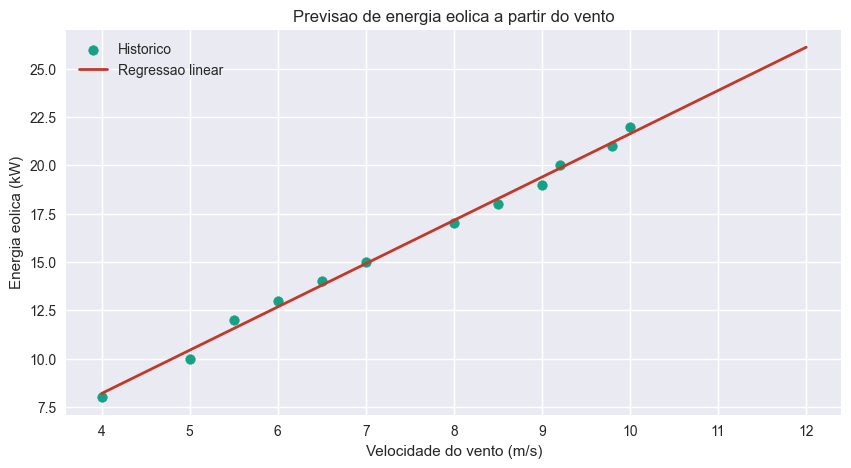

In [9]:
ventos = np.linspace(historico["vento_ms"].min(), historico["vento_ms"].max() + 2, 30)
linha_eolica = prever(a_vento, b_vento, ventos)

residuos = historico["energia_eolica_kw"] - prever(a_vento, b_vento, historico["vento_ms"])
print(f"Residuos -> media = {residuos.mean():+.3f} kW, desvio = {residuos.std():.3f} kW")

plt.figure(figsize=(10, 5))
plt.scatter(historico["vento_ms"], historico["energia_eolica_kw"], color="#16a085", label="Historico")
plt.plot(ventos, linha_eolica, color="#c0392b", linewidth=2, label="Regressao linear")
plt.title("Previsao de energia eolica a partir do vento")
plt.xlabel("Velocidade do vento (m/s)")
plt.ylabel("Energia eolica (kW)")
plt.grid(True)
plt.legend()
plt.show()

## 6. Analise de eficiencia energetica

A analise compara geracao, consumo e reserva e gera uma recomendacao de operacao.
Os cenarios sao organizados como uma **matriz (array 2D) do NumPy** - cada linha um cenario, cada coluna uma variavel. Os saldos sao calculados de forma vetorizada, sem laco Python.

In [10]:
def analisar_eficiencia(geracao_solar_kw, geracao_eolica_kw, consumo_kw, reserva_pct):
    geracao_total = geracao_solar_kw + geracao_eolica_kw
    saldo = geracao_total - consumo_kw
    proporcao_renovavel = geracao_total / max(consumo_kw, 1e-6)

    if saldo < 0 and reserva_pct < 30:
        recomendacao = "ALERTA: reduzir consumo e ativar modo economia"
    elif saldo < 0:
        recomendacao = "ATENCAO: usar reserva, monitorar consumo"
    elif saldo > 0 and reserva_pct < 80:
        recomendacao = "OK: carregar baterias com excedente"
    elif saldo > 0:
        recomendacao = "SUGESTAO: liberar carga para tarefas opcionais"
    else:
        recomendacao = "OK: operacao equilibrada"

    return {
        "geracao_total_kw": geracao_total,
        "saldo_kw": saldo,
        "proporcao_renovavel": proporcao_renovavel,
        "recomendacao": recomendacao,
    }


cenarios_matriz = np.array([
    [ 0, 20, 45, 25],
    [32, 18, 45, 64],
    [30, 22, 30, 95],
    [10,  8, 50, 15],
], dtype=float)

print(f"Matriz de cenarios (array 2D do NumPy): shape = {cenarios_matriz.shape}")

solar_col   = cenarios_matriz[:, 0]
eolica_col  = cenarios_matriz[:, 1]
consumo_col = cenarios_matriz[:, 2]
reserva_col = cenarios_matriz[:, 3]

geracao_total = solar_col + eolica_col
saldo_vetor   = geracao_total - consumo_col

print(f"Geracao total por cenario (vetorizada): {geracao_total}")
print(f"Saldos energeticos        (vetorizada): {saldo_vetor}")

linhas = []
for c in cenarios_matriz:
    r = analisar_eficiencia(c[0], c[1], c[2], c[3])
    linhas.append({
        "solar_kw":   c[0],
        "eolica_kw":  c[1],
        "consumo_kw": c[2],
        "reserva_%":  c[3],
        "saldo_kw":   round(r["saldo_kw"], 1),
        "recomendacao": r["recomendacao"],
    })

df_cenarios = pd.DataFrame(linhas)
df_cenarios

Matriz de cenarios (array 2D do NumPy): shape = (4, 4)
Geracao total por cenario (vetorizada): [20. 50. 52. 18.]
Saldos energeticos        (vetorizada): [-25.   5.  22. -32.]


,solar_kw,eolica_kw,consumo_kw,reserva_%,saldo_kw,recomendacao
0,0.0,20.0,45.0,25.0,-25.0,ALERTA: reduzir consumo e ativar modo economia
1,32.0,18.0,45.0,64.0,5.0,OK: carregar baterias com excedente
2,30.0,22.0,30.0,95.0,22.0,SUGESTAO: liberar carga para tarefas opcionais
3,10.0,8.0,50.0,15.0,-32.0,ALERTA: reduzir consumo e ativar modo economia


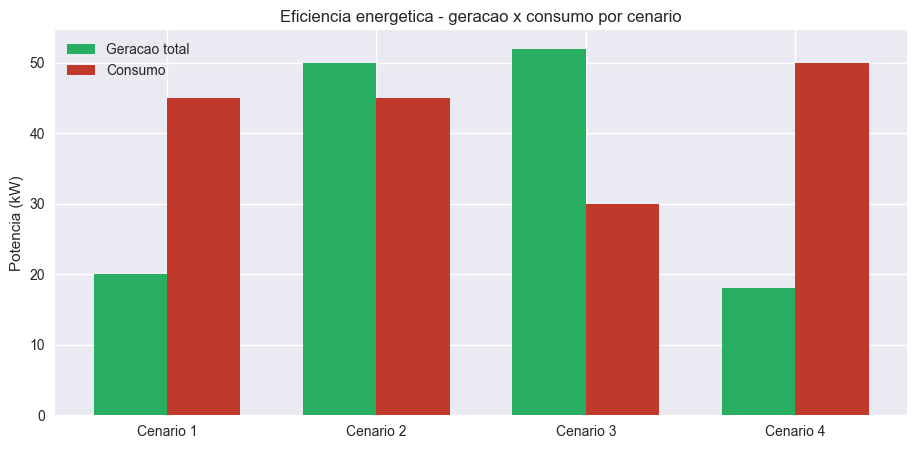

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
indices = np.arange(len(df_cenarios))
largura = 0.35

geracao_total = df_cenarios["solar_kw"] + df_cenarios["eolica_kw"]
ax.bar(indices - largura / 2, geracao_total, largura, label="Geracao total", color="#27ae60")
ax.bar(indices + largura / 2, df_cenarios["consumo_kw"], largura, label="Consumo", color="#c0392b")

ax.set_xticks(indices)
ax.set_xticklabels([f"Cenario {i+1}" for i in indices])
ax.set_ylabel("Potencia (kW)")
ax.set_title("Eficiencia energetica - geracao x consumo por cenario")
ax.legend()
ax.grid(True, axis="y")
plt.show()

## 7. Sistema integrado - entrada, processamento e saida

A funcao `executar_sistema` recebe a leitura atual dos sensores, usa a previsao (regressao linear), aplica as regras de decisao e gera uma saida operacional.

Fluxo: **dados -> previsao -> analise -> decisao -> acao**.

In [12]:
def executar_sistema(estado, hora_atual, modelos):
    a_v, b_v = modelos["eolica"]
    a_c, b_c = modelos["consumo"]

    vento = estado["ambiental"]["velocidade_vento_ms"]
    geracao_solar_kw = estado["energetico"]["solar"]["geracao_kw"]
    geracao_eolica_kw = estado["energetico"]["eolico"]["geracao_kw"]
    reserva = estado["energetico"]["reserva_bateria_pct"]
    consumo = estado["operacional"]["consumo_kw"]

    previsao_eolica = prever(a_v, b_v, vento)
    previsao_consumo = prever(a_c, b_c, hora_atual + 1)
    previsao_geracao = geracao_solar_kw + previsao_eolica

    analise = analisar_eficiencia(geracao_solar_kw, geracao_eolica_kw, consumo, reserva)
    modo = decidir_modo_operacao(
        geracao=geracao_solar_kw + geracao_eolica_kw,
        consumo=consumo,
        reserva=reserva,
        previsao_geracao=previsao_geracao,
    )
    modulos = priorizar_modulos(estado["operacional"]["modulos"], modo)

    return {
        "hora": hora_atual,
        "previsao_eolica_kw": round(previsao_eolica, 1),
        "previsao_consumo_kw": round(previsao_consumo, 1),
        "saldo_atual_kw": round(analise["saldo_kw"], 1),
        "recomendacao": analise["recomendacao"],
        "modo_operacao": modo,
        "modulos": modulos,
    }


modelos = {"eolica": (a_vento, b_vento), "consumo": (a_cons, b_cons)}
resultado = executar_sistema(colonia, hora_atual=9, modelos=modelos)

print("=== RESULTADO DO SISTEMA ===")
for chave, valor in resultado.items():
    if chave == "modulos":
        print("modulos:")
        for nome, dados in valor.items():
            estado_str = "LIGADO " if dados["ligado"] else "DESLIG."
            print(f"  - {nome:14s} {estado_str} consumo={dados['consumo_kw']} kW essencial={dados['essencial']}")
    else:
        print(f"{chave}: {valor}")

=== RESULTADO DO SISTEMA ===
hora: 9
previsao_eolica_kw: 19.8
previsao_consumo_kw: 48.5
saldo_atual_kw: 5.0
recomendacao: OK: carregar baterias com excedente
modo_operacao: MODO NORMAL
modulos:
  - suporte_vida   LIGADO  consumo=18.0 kW essencial=True
  - habitacao      LIGADO  consumo=9.0 kW essencial=True
  - laboratorio    LIGADO  consumo=7.0 kW essencial=False
  - estufa         LIGADO  consumo=6.0 kW essencial=False
  - comunicacao    LIGADO  consumo=5.0 kW essencial=True


## 8. Simulacao ao longo do dia

Executa o sistema para cada hora do historico, mostrando como ele evolui entre modos `NORMAL`, `ECONOMIA`, `EXCEDENTE` e `CRITICO`.

In [13]:
n = historico["hora"].size
reservas = np.maximum(10, 90 - np.arange(n) * 5).astype(float)

saldos_vetorizados = (
    historico["geracao_solar_kw"]
    + historico["energia_eolica_kw"]
    - historico["consumo_kw"]
)
print(f"Saldos energeticos do dia (vetorizado com NumPy): {saldos_vetorizados}")
print(f"  - saldo medio = {saldos_vetorizados.mean():+.2f} kW")
print(f"  - saldo minimo = {saldos_vetorizados.min():+.2f} kW")

linhas_simulacao = []
for i in range(n):
    estado = {
        "energetico": {
            "solar":  {"geracao_kw": float(historico["geracao_solar_kw"][i]),  "status": "ok"},
            "eolico": {"geracao_kw": float(historico["energia_eolica_kw"][i]), "status": "ok"},
            "reserva_bateria_pct": float(reservas[i]),
        },
        "ambiental": {
            "temperatura_interna_c": 21.5,
            "temperatura_externa_c": -58.0,
            "velocidade_vento_ms": float(historico["vento_ms"][i]),
        },
        "operacional": {
            "consumo_kw": float(historico["consumo_kw"][i]),
            "modulos": colonia["operacional"]["modulos"],
        },
    }
    r = executar_sistema(estado, hora_atual=int(historico["hora"][i]), modelos=modelos)
    linhas_simulacao.append({
        "hora": r["hora"],
        "saldo_kw": r["saldo_atual_kw"],
        "previsao_eolica": r["previsao_eolica_kw"],
        "modo": r["modo_operacao"],
        "recomendacao": r["recomendacao"],
    })

df_simulacao = pd.DataFrame(linhas_simulacao)
df_simulacao

Saldos energeticos do dia (vetorizado com NumPy): [-30. -28. -23. -15.  -9.  -5.  -1.  -1.   0.  -2.  -7. -13.]
  - saldo medio = -11.17 kW
  - saldo minimo = -30.00 kW


,hora,saldo_kw,previsao_eolica,modo,recomendacao
0,0,-30.0,8.2,MODO NORMAL,"ATENCAO: usar reserva, monitorar consumo"
1,1,-28.0,10.4,MODO NORMAL,"ATENCAO: usar reserva, monitorar consumo"
2,2,-23.0,11.6,MODO NORMAL,"ATENCAO: usar reserva, monitorar consumo"
3,3,-15.0,12.7,MODO NORMAL,"ATENCAO: usar reserva, monitorar consumo"
4,4,-9.0,13.8,MODO NORMAL,"ATENCAO: usar reserva, monitorar consumo"
5,5,-5.0,14.9,MODO NORMAL,"ATENCAO: usar reserva, monitorar consumo"
6,6,-1.0,17.1,MODO NORMAL,"ATENCAO: usar reserva, monitorar consumo"
7,7,-1.0,18.3,MODO NORMAL,"ATENCAO: usar reserva, monitorar consumo"
8,8,0.0,19.4,MODO NORMAL,OK: operacao equilibrada
9,9,-2.0,19.8,MODO ECONOMIA,"ATENCAO: usar reserva, monitorar consumo"


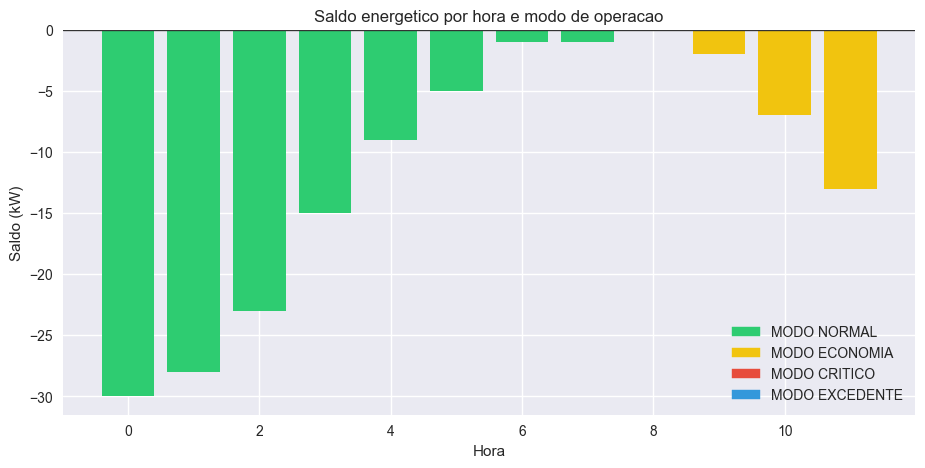

In [14]:
cores_modo = {
    "MODO NORMAL":    "#2ecc71",
    "MODO ECONOMIA":  "#f1c40f",
    "MODO CRITICO":   "#e74c3c",
    "MODO EXCEDENTE": "#3498db",
}
cores = df_simulacao["modo"].map(cores_modo)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(df_simulacao["hora"], df_simulacao["saldo_kw"], color=cores)
ax.axhline(0, color="#333", linewidth=1)
ax.set_title("Saldo energetico por hora e modo de operacao")
ax.set_xlabel("Hora")
ax.set_ylabel("Saldo (kW)")

import matplotlib.patches as mpatches
legendas = [mpatches.Patch(color=cor, label=modo) for modo, cor in cores_modo.items()]
ax.legend(handles=legendas, loc="lower right")
ax.grid(True, axis="y")
plt.show()

## 9. Conclusao

O sistema desenvolvido cobre o ciclo completo proposto na atividade:

- **Estruturacao de dados** com listas, dicionarios e hierarquias.
- **Regras de decisao** com condicoes simples e combinadas.
- **Modelagem matematica** com funcoes para geracao e consumo.
- **Previsao** com regressao linear implementada na mao.
- **Eficiencia energetica** com recomendacoes automaticas.

Ele evolui de uma resposta apenas reativa para uma resposta preditiva, antecipando situacoes e priorizando o suporte a vida quando necessario.